# Margem e issue tree — case Vértice / MIPO\n\nNotebook organizado para publicação. Os caminhos de dados são relativos a `../data/`. As bases brutas não acompanham o repositório público. Resultados representam evidência histórica ou estimativa; associação não implica causalidade e exposição não equivale a perda comprovada.

# Projeto Vértice - EDA diagnóstica de margem e issue tree

Este notebook cria uma investigação adicional sobre os dados em `case/data`, com foco em hipóteses de problemas que mais impactam a margem.

A metodologia foi inspirada no PDF `#06 Análise Exploratória e Diagnóstico com IA - Felipe Botelho.pdf`, usado aqui como guia metodológico, não como uma lista de comandos do usuário. A adaptação aplicada neste case segue o ciclo: perfilar -> tratar -> explorar -> testar hipótese -> sintetizar.

## Premissas de leitura do PDF

Do material, foram aproveitados os seguintes princípios:

- Identificar grão, período, dicionário implícito, chaves e lacunas antes da análise.
- Separar análise descritiva, diagnóstica, preditiva e prescritiva.
- Abrir a margem por cortes de negócio antes de confiar no consolidado.
- Tratar correlação como hipótese, não como causa.
- Calcular números deterministicamente em Python e usar síntese apenas para organizar decisões.

A atividade prática de FitNutri no PDF não foi executada literalmente, porque o pedido atual é analisar `bootcamp-elo/case/data`.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except Exception:
    sns = None

from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

def format_table(df, money=None, pct=None, decimals=None):
    """Return a display-friendly copy without requiring pandas Styler/jinja2."""
    out = df.copy()
    money = money or []
    pct = pct or []
    decimals = decimals or []
    for col in money:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"R$ {x:,.0f}" if pd.notna(x) else np.nan)
    for col in pct:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else np.nan)
    for col in decimals:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:,.2f}" if pd.notna(x) else np.nan)
    return out


ModuleNotFoundError: No module named 'scipy'

In [ ]:
def read_csv(name):
    df = pd.read_csv(DATA_DIR / name, encoding='utf-8-sig')
    df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()
    return df

vendas_raw = read_csv('vendas.csv')
marketing_raw = read_csv('marketing.csv')
atendimento_raw = read_csv('atendimento.csv')
clientes_raw = read_csv('clientes.csv')
estoque_raw = read_csv('estoque.csv')

datasets_raw = {
    'vendas': vendas_raw,
    'marketing': marketing_raw,
    'atendimento': atendimento_raw,
    'clientes': clientes_raw,
    'estoque': estoque_raw,
}

profile = []
for name, df in datasets_raw.items():
    date_cols = [c for c in df.columns if c.startswith('data_')]
    profile.append({
        'base': name,
        'linhas': len(df),
        'colunas': df.shape[1],
        'nulos_total': int(df.isna().sum().sum()),
        'colunas_data': ', '.join(date_cols),
        'possivel_grao': {
            'vendas': 'item/pedido vendido, 1 order_id por linha nesta base',
            'marketing': 'campanha de marketing',
            'atendimento': 'ticket de atendimento',
            'clientes': 'cliente',
            'estoque': 'SKU/produto',
        }[name],
    })

pd.DataFrame(profile)

,base,linhas,colunas,nulos_total,colunas_data,possivel_grao
0,vendas,27759,20,13,data_pedido,"item/pedido vendido, 1 order_id por linha nest..."
1,marketing,3500,15,0,"data_inicio, data_fim",campanha de marketing
2,atendimento,35841,12,12,"data_abertura, data_fechamento",ticket de atendimento
3,clientes,15000,14,0,"data_nascimento, data_cadastro",cliente
4,estoque,5000,16,0,data_ultima_entrada,SKU/produto


In [ ]:
# Tipagem controlada e isolamento de linhas inviáveis.
vendas = vendas_raw.copy()
marketing = marketing_raw.copy()
atendimento = atendimento_raw.copy()
clientes = clientes_raw.copy()
estoque = estoque_raw.copy()

for col in ['quantidade', 'preco_unitario', 'receita_bruta', 'desconto_reais', 'receita_liquida',
            'custo_produto', 'custo_frete', 'margem_contribuicao', 'tempo_entrega_real']:
    vendas[col] = pd.to_numeric(vendas[col], errors='coerce')
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'], errors='coerce')
vendas['devolvido_bool'] = vendas['devolvido'].map({'True': True, 'False': False, True: True, False: False})

for col in ['investimento_reais', 'impressoes', 'cliques', 'conversoes', 'roas', 'receita_gerada', 'cac']:
    marketing[col] = pd.to_numeric(marketing[col], errors='coerce')
marketing['data_inicio'] = pd.to_datetime(marketing['data_inicio'], errors='coerce')
marketing['data_fim'] = pd.to_datetime(marketing['data_fim'], errors='coerce')

for col in ['nota_csat', 'tempo_primeira_resposta_minutos', 'custo_operacional_ticket']:
    atendimento[col] = pd.to_numeric(atendimento[col], errors='coerce')
atendimento['data_abertura'] = pd.to_datetime(atendimento['data_abertura'], errors='coerce')
atendimento['data_fechamento'] = pd.to_datetime(atendimento['data_fechamento'], errors='coerce')

for col in ['lead_time_reposicao', 'custo_unitario', 'preco_venda_sugerido', 'estoque_fisico',
            'estoque_reservado', 'estoque_disponivel', 'ponto_pedido', 'shelf_life_dias', 'volume_m3']:
    estoque[col] = pd.to_numeric(estoque[col], errors='coerce')
estoque['data_ultima_entrada'] = pd.to_datetime(estoque['data_ultima_entrada'], errors='coerce')

clientes['data_cadastro'] = pd.to_datetime(clientes['data_cadastro'], errors='coerce')
clientes['data_nascimento'] = pd.to_datetime(clientes['data_nascimento'], errors='coerce')

quality_checks = pd.DataFrame([
    {'check': 'vendas: order_id unico', 'resultado': vendas['order_id'].is_unique, 'evidencia': f"duplicados={vendas['order_id'].duplicated().sum()}"},
    {'check': 'vendas: reconcilia receita bruta - desconto = liquida', 'resultado': ((vendas['receita_bruta'] - vendas['desconto_reais'] - vendas['receita_liquida']).abs().dropna() < 0.02).all(), 'evidencia': f"erro_max={(vendas['receita_bruta'] - vendas['desconto_reais'] - vendas['receita_liquida']).abs().max():.4f}"},
    {'check': 'vendas: data valida', 'resultado': vendas['data_pedido'].notna().all(), 'evidencia': f"datas_invalidas={vendas['data_pedido'].isna().sum()}"},
    {'check': 'atendimento: ticket_id TKT-* e CSAT 1-5', 'resultado': bool((atendimento['ticket_id'].str.startswith('TKT-', na=False) & atendimento['nota_csat'].between(1, 5)).all()), 'evidencia': f"linhas_invalidas={(~(atendimento['ticket_id'].str.startswith('TKT-', na=False) & atendimento['nota_csat'].between(1, 5))).sum()}"},
    {'check': 'chave vendas -> clientes', 'resultado': vendas['customer_id'].dropna().isin(clientes['customer_id']).all(), 'evidencia': f"clientes_sem_cadastro={(~vendas['customer_id'].dropna().isin(clientes['customer_id'])).sum()}"},
    {'check': 'chave vendas -> estoque/SKU', 'resultado': vendas['sku_id'].dropna().isin(estoque['sku_id']).all(), 'evidencia': f"skus_sem_cadastro={(~vendas['sku_id'].dropna().isin(estoque['sku_id'])).sum()}"},
])
quality_checks

,check,resultado,evidencia
0,vendas: order_id unico,True,duplicados=0
1,vendas: reconcilia receita bruta - desconto = ...,True,erro_max=0.0000
2,vendas: data valida,True,datas_invalidas=0
3,atendimento: ticket_id TKT-* e CSAT 1-5,False,linhas_invalidas=2
4,chave vendas -> clientes,True,clientes_sem_cadastro=0
5,chave vendas -> estoque/SKU,True,skus_sem_cadastro=0


## Escopo financeiro

A base principal de margem usa apenas vendas com `status_pagamento == "Aprovado"`, pois cancelados e aguardando não devem ser tratados como margem realizada. Esta escolha reduz viés, mas também significa que a análise não estima receita perdida por pagamentos recusados.

In [ ]:
vendas_fin = vendas[
    (vendas['status_pagamento'] == 'Aprovado') &
    vendas['receita_liquida'].notna() &
    vendas['margem_contribuicao'].notna() &
    (vendas['receita_liquida'] > 0)
].copy()

vendas_fin['margem_pct_linha'] = vendas_fin['margem_contribuicao'] / vendas_fin['receita_liquida']
vendas_fin['frete_pct_linha'] = vendas_fin['custo_frete'] / vendas_fin['receita_liquida']
vendas_fin['desconto_pct_linha'] = vendas_fin['desconto_reais'] / vendas_fin['receita_bruta'].replace(0, np.nan)
vendas_fin['mes'] = vendas_fin['data_pedido'].dt.to_period('M').dt.to_timestamp()
vendas_fin['faixa_ticket'] = pd.cut(
    vendas_fin['receita_liquida'],
    bins=[0, 100, 200, 400, 800, np.inf],
    labels=['<=100', '101-200', '201-400', '401-800', '>800'],
    include_lowest=True,
)

financial_scope = pd.DataFrame([
    {'metrica': 'linhas em vendas.csv', 'valor': len(vendas)},
    {'metrica': 'linhas financeiras aprovadas', 'valor': len(vendas_fin)},
    {'metrica': 'linhas excluidas por status/nulos', 'valor': len(vendas) - len(vendas_fin)},
    {'metrica': 'inicio vendas aprovadas', 'valor': vendas_fin['data_pedido'].min()},
    {'metrica': 'fim vendas aprovadas', 'valor': vendas_fin['data_pedido'].max()},
    {'metrica': 'receita liquida aprovada', 'valor': vendas_fin['receita_liquida'].sum()},
    {'metrica': 'margem contribuicao aprovada', 'valor': vendas_fin['margem_contribuicao'].sum()},
    {'metrica': 'margem % aprovada', 'valor': vendas_fin['margem_contribuicao'].sum() / vendas_fin['receita_liquida'].sum()},
])
financial_scope

,metrica,valor
0,linhas em vendas.csv,27759
1,linhas financeiras aprovadas,24454
2,linhas excluidas por status/nulos,3305
3,inicio vendas aprovadas,2023-01-01 00:05:25
4,fim vendas aprovadas,2024-01-26 10:53:49
5,receita liquida aprovada,"16,668,956.49"
6,margem contribuicao aprovada,"9,058,427.55"
7,margem % aprovada,0.54


## Hipotese 1 - canal e frete diluem margem

Teste: comparar margem, frete e desconto por canal. Se um canal tem margem menor e custo de frete mais alto, a hipótese ganha força. O benchmark usado é a margem dos canais que não são Marketplace.

In [ ]:
def summarize_sales(df, dims):
    grouped = df.groupby(dims, observed=True).agg(
        pedidos=('order_id', 'count'),
        clientes=('customer_id', 'nunique'),
        receita=('receita_liquida', 'sum'),
        margem=('margem_contribuicao', 'sum'),
        frete=('custo_frete', 'sum'),
        desconto=('desconto_reais', 'sum'),
        devolucao=('devolvido_bool', 'mean'),
        ticket_medio=('receita_liquida', 'mean'),
        ticket_mediano=('receita_liquida', 'median'),
    )
    grouped['margem_pct'] = grouped['margem'] / grouped['receita']
    grouped['share_receita'] = grouped['receita'] / df['receita_liquida'].sum()
    grouped['frete_pct'] = grouped['frete'] / grouped['receita']
    grouped['desconto_pct'] = grouped['desconto'] / (grouped['receita'] + grouped['desconto'])
    return grouped.sort_values('margem_pct')

channel_summary = summarize_sales(vendas_fin, 'canal')
format_table(
    channel_summary.reset_index(),
    money=['receita', 'margem', 'frete', 'desconto', 'ticket_medio', 'ticket_mediano'],
    pct=['margem_pct', 'share_receita', 'frete_pct', 'desconto_pct', 'devolucao'],
)

,canal,pedidos,clientes,receita,margem,frete,desconto,devolucao,ticket_medio,ticket_mediano,margem_pct,share_receita,frete_pct,desconto_pct
0,Marketplace,5315,156,"R$ 3,527,695","R$ 1,816,773","R$ 172,829","R$ 291,132",15.18%,R$ 664,R$ 532,51.50%,21.16%,4.90%,7.62%
1,Google Ads,4852,156,"R$ 3,226,403","R$ 1,769,102","R$ 31,773","R$ 299,628",15.19%,R$ 665,R$ 528,54.83%,19.36%,0.98%,8.50%
2,Instagram Ads,4385,154,"R$ 2,891,577","R$ 1,587,841","R$ 29,349","R$ 257,567",14.82%,R$ 659,R$ 531,54.91%,17.35%,1.01%,8.18%
3,Orgânico,2864,121,"R$ 1,897,092","R$ 1,045,512","R$ 20,977","R$ 157,967",14.49%,R$ 662,R$ 521,55.11%,11.38%,1.11%,7.69%
4,TikTok Ads,2568,104,"R$ 1,663,326","R$ 917,972","R$ 18,534","R$ 149,996",14.60%,R$ 648,R$ 523,55.19%,9.98%,1.11%,8.27%
5,Influenciador,2006,91,"R$ 1,809,238","R$ 1,002,647","R$ 7,571","R$ 167,212",15.05%,R$ 902,R$ 732,55.42%,10.85%,0.42%,8.46%
6,Email Marketing,2464,111,"R$ 1,653,627","R$ 918,580","R$ 16,737","R$ 126,565",14.33%,R$ 671,R$ 530,55.55%,9.92%,1.01%,7.11%


In [ ]:
overall_margin_pct = vendas_fin['margem_contribuicao'].sum() / vendas_fin['receita_liquida'].sum()
marketplace = vendas_fin[vendas_fin['canal'] == 'Marketplace']
non_marketplace = vendas_fin[vendas_fin['canal'] != 'Marketplace']

mkt_margin_pct = marketplace['margem_contribuicao'].sum() / marketplace['receita_liquida'].sum()
non_mkt_margin_pct = non_marketplace['margem_contribuicao'].sum() / non_marketplace['receita_liquida'].sum()
mkt_frete_pct = marketplace['custo_frete'].sum() / marketplace['receita_liquida'].sum()
non_mkt_frete_pct = non_marketplace['custo_frete'].sum() / non_marketplace['receita_liquida'].sum()

channel_margin_gap = (non_mkt_margin_pct - mkt_margin_pct) * marketplace['receita_liquida'].sum()
freight_gap = (mkt_frete_pct - non_mkt_frete_pct) * marketplace['receita_liquida'].sum()

channel_diagnosis = pd.DataFrame([
    {'indicador': 'Margem total aprovada', 'valor': overall_margin_pct, 'leitura': 'base de comparacao'},
    {'indicador': 'Margem Marketplace', 'valor': mkt_margin_pct, 'leitura': 'menor margem entre os canais'},
    {'indicador': 'Margem sem Marketplace', 'valor': non_mkt_margin_pct, 'leitura': 'benchmark operacional interno'},
    {'indicador': 'Frete Marketplace / receita', 'valor': mkt_frete_pct, 'leitura': 'custo de frete concentrado'},
    {'indicador': 'Frete sem Marketplace / receita', 'valor': non_mkt_frete_pct, 'leitura': 'benchmark de frete dos demais canais'},
    {'indicador': 'Gap de margem se Marketplace igualasse demais canais', 'valor': channel_margin_gap, 'leitura': 'oportunidade teorica observada'},
    {'indicador': 'Excesso de frete Marketplace vs demais canais', 'valor': freight_gap, 'leitura': 'principal explicacao numerica do gap'},
])
channel_diagnosis

,indicador,valor,leitura
0,Margem total aprovada,0.54,base de comparacao
1,Margem Marketplace,0.52,menor margem entre os canais
2,Margem sem Marketplace,0.55,benchmark operacional interno
3,Frete Marketplace / receita,0.05,custo de frete concentrado
4,Frete sem Marketplace / receita,0.01,benchmark de frete dos demais canais
5,Gap de margem se Marketplace igualasse demais ...,"127,206.65",oportunidade teorica observada
6,Excesso de frete Marketplace vs demais canais,"139,288.96",principal explicacao numerica do gap


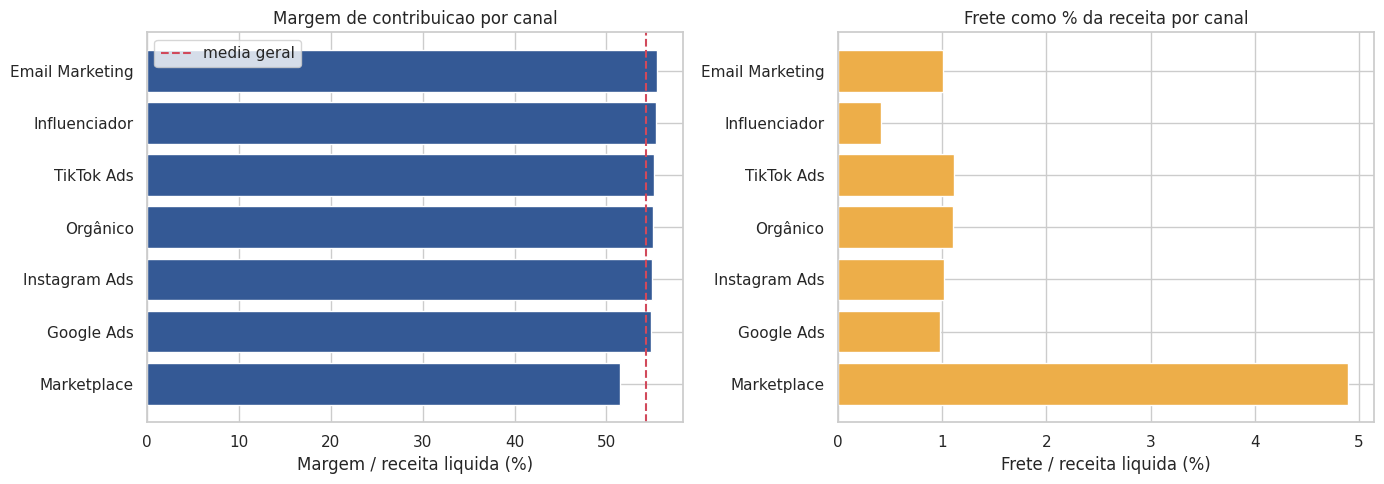

In [ ]:
plot_channel = channel_summary.reset_index().sort_values('margem_pct')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_channel['canal'], plot_channel['margem_pct'] * 100, color='#345995')
axes[0].axvline(overall_margin_pct * 100, color='#d1495b', linestyle='--', label='media geral')
axes[0].set_title('Margem de contribuicao por canal')
axes[0].set_xlabel('Margem / receita liquida (%)')
axes[0].legend()

axes[1].barh(plot_channel['canal'], plot_channel['frete_pct'] * 100, color='#edae49')
axes[1].set_title('Frete como % da receita por canal')
axes[1].set_xlabel('Frete / receita liquida (%)')
plt.tight_layout()
plt.show()

In [ ]:
frete_faixa = vendas_fin.groupby(['canal', 'faixa_ticket'], observed=True).agg(
    pedidos=('order_id', 'count'),
    receita=('receita_liquida', 'sum'),
    frete=('custo_frete', 'sum'),
).reset_index()
frete_faixa['frete_pct'] = frete_faixa['frete'] / frete_faixa['receita']

marketplace_ticket_freight = frete_faixa[frete_faixa['canal'] == 'Marketplace'].copy()
format_table(
    marketplace_ticket_freight,
    money=['receita', 'frete'],
    pct=['frete_pct'],
)

,canal,faixa_ticket,pedidos,receita,frete,frete_pct
20,Marketplace,<=100,197,"R$ 14,295","R$ 6,255",43.76%
21,Marketplace,101-200,625,"R$ 95,249","R$ 20,345",21.36%
22,Marketplace,201-400,1245,"R$ 365,116","R$ 40,999",11.23%
23,Marketplace,401-800,1601,"R$ 938,649","R$ 51,268",5.46%
24,Marketplace,>800,1647,"R$ 2,114,385","R$ 53,962",2.55%


## Hipotese 2 - descontos explicam a queda de margem

Teste: comparar desconto como percentual da receita bruta por canal e verificar se os canais de maior desconto sao os de menor margem. Se a relacao nao aparecer nos cortes, a hipótese perde prioridade.

In [ ]:
discount_check = channel_summary[['receita', 'margem_pct', 'desconto_pct', 'share_receita']].sort_values('desconto_pct', ascending=False)
cor_discount_margin = channel_summary['desconto_pct'].corr(channel_summary['margem_pct'])

discount_diagnosis = discount_check.copy()
discount_diagnosis['correlacao_desconto_margem_no_corte_canal'] = cor_discount_margin
format_table(
    discount_diagnosis.reset_index(),
    money=['receita'],
    pct=['margem_pct', 'desconto_pct', 'share_receita'],
    decimals=['correlacao_desconto_margem_no_corte_canal'],
)

,canal,receita,margem_pct,desconto_pct,share_receita,correlacao_desconto_margem_no_corte_canal
0,Google Ads,"R$ 3,226,403",54.83%,8.50%,19.36%,0.20
1,Influenciador,"R$ 1,809,238",55.42%,8.46%,10.85%,0.20
2,TikTok Ads,"R$ 1,663,326",55.19%,8.27%,9.98%,0.20
3,Instagram Ads,"R$ 2,891,577",54.91%,8.18%,17.35%,0.20
4,Orgânico,"R$ 1,897,092",55.11%,7.69%,11.38%,0.20
5,Marketplace,"R$ 3,527,695",51.50%,7.62%,21.16%,0.20
6,Email Marketing,"R$ 1,653,627",55.55%,7.11%,9.92%,0.20


## Hipotese 3 - devolucoes e qualidade operacional consomem margem

Teste: quantificar volume financeiro de pedidos devolvidos e procurar concentracao por canal, categoria e motivo. A base marca devolucao, mas nao informa estorno, custo reverso ou recuperacao; por isso o valor abaixo e exposicao de margem, nao perda contábil comprovada.

In [ ]:
returns = vendas_fin[vendas_fin['devolvido_bool'] == True].copy()
return_summary = pd.DataFrame([
    {'indicador': 'taxa de devolucao aprovada', 'valor': vendas_fin['devolvido_bool'].mean()},
    {'indicador': 'pedidos devolvidos', 'valor': len(returns)},
    {'indicador': 'receita liquida em pedidos devolvidos', 'valor': returns['receita_liquida'].sum()},
    {'indicador': 'margem em pedidos devolvidos', 'valor': returns['margem_contribuicao'].sum()},
])

return_by_reason = returns.groupby('motivo_devolucao').agg(
    pedidos=('order_id', 'count'),
    receita=('receita_liquida', 'sum'),
    margem=('margem_contribuicao', 'sum'),
).sort_values('receita', ascending=False)
return_by_reason['share_receita_devolvida'] = return_by_reason['receita'] / returns['receita_liquida'].sum()

def cramers_v(df, dim):
    tab = pd.crosstab(df[dim], df['devolvido_bool'])
    chi2, pvalue, dof, expected = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    k = min(tab.shape) - 1
    value = np.sqrt(chi2 / (n * k)) if k else np.nan
    return {'dimensao': dim, 'p_value': pvalue, 'cramers_v': value}

return_assoc = pd.DataFrame([cramers_v(vendas_fin, dim) for dim in ['canal', 'categoria', 'faixa_ticket']])

print('Resumo de devolucoes')
display(return_summary)
print('\nMotivos de devolucao')
display(format_table(
    return_by_reason.reset_index(),
    money=['receita', 'margem'],
    pct=['share_receita_devolvida'],
))
print('\nAssociacao estatistica com devolucao')
display(format_table(return_assoc, decimals=['p_value', 'cramers_v']))

Resumo de devolucoes


,indicador,valor
0,taxa de devolucao aprovada,0.15
1,pedidos devolvidos,"3,639.00"
2,receita liquida em pedidos devolvidos,"2,500,436.46"
3,margem em pedidos devolvidos,"1,351,707.09"



Motivos de devolucao


,motivo_devolucao,pedidos,receita,margem,share_receita_devolvida
0,Produto com defeito,919,"R$ 647,606","R$ 355,377",25.90%
1,Tamanho errado,911,"R$ 614,352","R$ 325,178",24.57%
2,Atraso na entrega,711,"R$ 473,223","R$ 258,617",18.93%
3,Não gostei,589,"R$ 420,333","R$ 226,833",16.81%
4,Arrependimento,509,"R$ 344,921","R$ 185,702",13.79%



Associacao estatistica com devolucao


,dimensao,p_value,cramers_v
0,canal,0.93,0.01
1,categoria,0.39,0.01
2,faixa_ticket,0.82,0.01


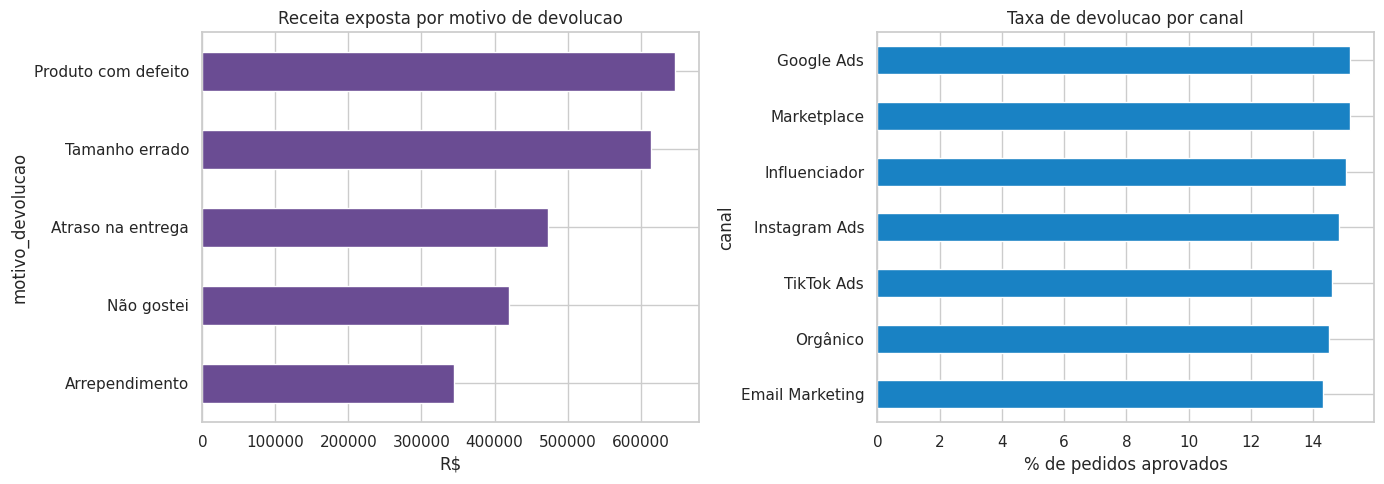

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
return_by_reason['receita'].sort_values().plot(kind='barh', ax=axes[0], color='#6a4c93')
axes[0].set_title('Receita exposta por motivo de devolucao')
axes[0].set_xlabel('R$')

return_rate_channel = vendas_fin.groupby('canal')['devolvido_bool'].mean().sort_values()
return_rate_channel.mul(100).plot(kind='barh', ax=axes[1], color='#1982c4')
axes[1].set_title('Taxa de devolucao por canal')
axes[1].set_xlabel('% de pedidos aprovados')
plt.tight_layout()
plt.show()

## Hipotese 4 - atendimento revela custo de servir e atrito logistico

Teste: validar tickets utilizaveis, quantificar custo operacional por problema e conectar tickets a pedidos aprovados. Esse custo nao aparece explicitamente em `margem_contribuicao`, portanto e tratado como vazamento operacional adicional.

In [ ]:
atendimento_valid = atendimento[
    atendimento['ticket_id'].str.startswith('TKT-', na=False) &
    atendimento['nota_csat'].between(1, 5) &
    atendimento['order_id'].notna()
].copy()

support_by_problem = atendimento_valid.groupby('categoria_problema').agg(
    tickets=('ticket_id', 'count'),
    custo=('custo_operacional_ticket', 'sum'),
    csat=('nota_csat', 'mean'),
    p90_primeira_resposta=('tempo_primeira_resposta_minutos', lambda s: s.quantile(0.90)),
).sort_values('tickets', ascending=False)
support_by_problem['share_tickets'] = support_by_problem['tickets'] / support_by_problem['tickets'].sum()

support_sales = atendimento_valid.merge(
    vendas_fin[['order_id', 'canal', 'categoria', 'receita_liquida', 'margem_contribuicao', 'devolvido_bool', 'tempo_entrega_real']],
    on='order_id', how='inner'
)

support_joined_by_problem = support_sales.groupby('categoria_problema').agg(
    tickets=('ticket_id', 'count'),
    pedidos=('order_id', 'nunique'),
    custo=('custo_operacional_ticket', 'sum'),
    receita=('receita_liquida', 'sum'),
    csat=('nota_csat', 'mean'),
).sort_values('custo', ascending=False)
support_joined_by_problem['custo_pct_receita'] = support_joined_by_problem['custo'] / support_joined_by_problem['receita']

print('Tickets validos:', len(atendimento_valid), '| tickets conectados a vendas aprovadas:', len(support_sales))
display(format_table(
    support_by_problem.reset_index(),
    money=['custo'],
    pct=['share_tickets'],
    decimals=['csat', 'p90_primeira_resposta'],
))
display(format_table(
    support_joined_by_problem.reset_index(),
    money=['custo', 'receita'],
    pct=['custo_pct_receita'],
    decimals=['csat'],
))

Tickets validos: 35839 | tickets conectados a vendas aprovadas: 10965


,categoria_problema,tickets,custo,csat,p90_primeira_resposta,share_tickets
0,Onde está meu pedido?,10765,"R$ 159,660",2.99,422.00,30.04%
1,Defeito,6509,"R$ 96,592",2.82,417.00,18.16%
2,Troca de Tamanho,5359,"R$ 79,310",2.99,412.00,14.95%
3,Dúvida Técnica,5314,"R$ 78,888",3.83,419.00,14.83%
4,Pagamento não aprovado,4281,"R$ 63,856",2.99,410.00,11.95%
5,Elogio,3611,"R$ 53,939",4.57,415.00,10.08%


,categoria_problema,tickets,pedidos,custo,receita,csat,custo_pct_receita
0,Onde está meu pedido?,3279,3071,"R$ 48,202","R$ 2,224,339",3.00,2.17%
1,Defeito,1925,1861,"R$ 28,230","R$ 1,336,421",2.79,2.11%
2,Troca de Tamanho,1644,1592,"R$ 24,717","R$ 1,137,628",2.99,2.17%
3,Dúvida Técnica,1646,1549,"R$ 24,674","R$ 1,161,830",3.84,2.12%
4,Pagamento não aprovado,1399,1333,"R$ 21,058","R$ 980,006",2.99,2.15%
5,Elogio,1072,1033,"R$ 15,804","R$ 761,258",4.57,2.08%


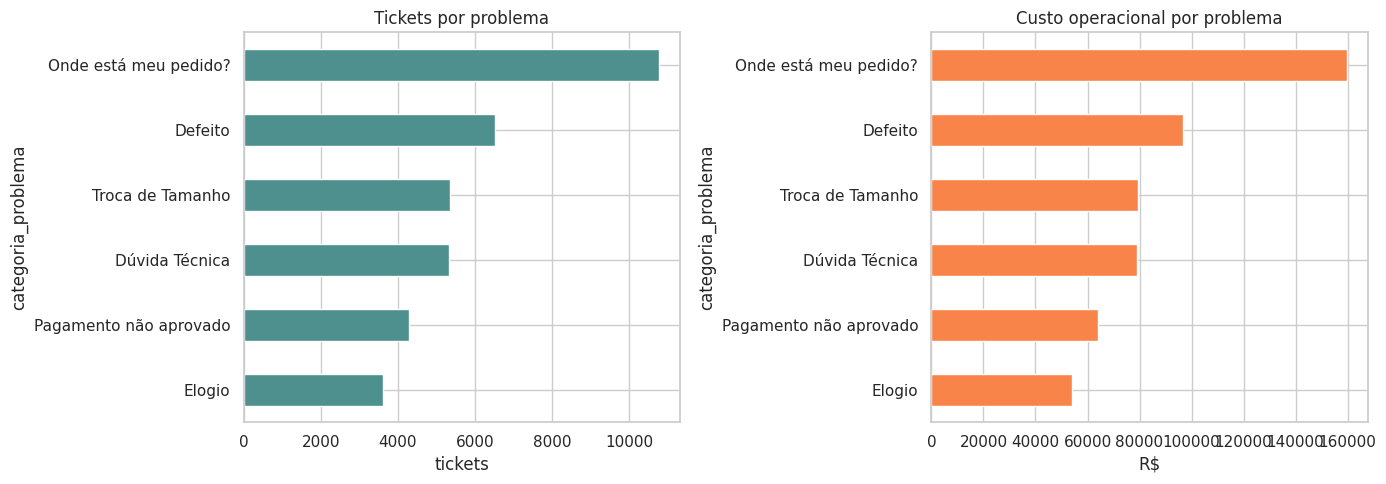

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
support_by_problem['tickets'].sort_values().plot(kind='barh', ax=axes[0], color='#4d908e')
axes[0].set_title('Tickets por problema')
axes[0].set_xlabel('tickets')

support_by_problem['custo'].sort_values().plot(kind='barh', ax=axes[1], color='#f9844a')
axes[1].set_title('Custo operacional por problema')
axes[1].set_xlabel('R$')
plt.tight_layout()
plt.show()

## Hipotese 5 - rupturas bloqueiam produtos rentaveis

Teste: cruzar status de estoque com venda historica por SKU. Como o estoque e um snapshot, esta hipotese mede risco/oportunidade futura, nao perda historica fechada.

In [ ]:
sku_sales = vendas_fin.groupby('sku_id').agg(
    pedidos_hist=('order_id', 'count'),
    receita_hist=('receita_liquida', 'sum'),
    margem_hist=('margem_contribuicao', 'sum'),
).reset_index()
sku_inventory = estoque.merge(sku_sales, on='sku_id', how='left')
for col in ['pedidos_hist', 'receita_hist', 'margem_hist']:
    sku_inventory[col] = sku_inventory[col].fillna(0)

inventory_status = sku_inventory.groupby('status_disponibilidade').agg(
    skus=('sku_id', 'count'),
    pedidos_hist=('pedidos_hist', 'sum'),
    receita_hist=('receita_hist', 'sum'),
    margem_hist=('margem_hist', 'sum'),
    margem_unitaria_catalogo=('preco_venda_sugerido', lambda s: np.nan),
).drop(columns=['margem_unitaria_catalogo'])
inventory_status['margem_pct_hist'] = inventory_status['margem_hist'] / inventory_status['receita_hist'].replace(0, np.nan)
inventory_status = inventory_status.sort_values('margem_hist', ascending=False)

rupture_top = sku_inventory[sku_inventory['status_disponibilidade'] == 'Ruptura'].sort_values('margem_hist', ascending=False).head(10)

print('Resumo por status de estoque')
display(format_table(
    inventory_status.reset_index(),
    money=['receita_hist', 'margem_hist'],
    pct=['margem_pct_hist'],
))
print('\nTop SKUs em ruptura por margem historica')
display(format_table(
    rupture_top[['sku_id', 'nome_produto', 'categoria', 'estoque_disponivel', 'ponto_pedido', 'receita_hist', 'margem_hist', 'pedidos_hist']],
    money=['receita_hist', 'margem_hist'],
))

Resumo por status de estoque


,status_disponibilidade,skus,pedidos_hist,receita_hist,margem_hist,margem_pct_hist
0,Em Estoque,3993,"19,665.00","R$ 13,358,598","R$ 7,259,932",54.35%
1,Estoque Crítico,701,"3,277.00","R$ 2,260,585","R$ 1,222,170",54.06%
2,Descontinuado,207,"1,003.00","R$ 709,145","R$ 387,237",54.61%
3,Ruptura,99,509.00,"R$ 340,629","R$ 189,089",55.51%



Top SKUs em ruptura por margem historica


,sku_id,nome_produto,categoria,estoque_disponivel,ponto_pedido,receita_hist,margem_hist,pedidos_hist
1566,SKU-01567,Óculos de Sol Urban Dourado,Acessórios,0,38,"R$ 10,382","R$ 5,488",11.00
2850,SKU-02851,Esfoliante Básico Dourado,Beleza,0,101,"R$ 8,738","R$ 5,112",6.00
3293,SKU-03294,Perfume Exclusivo Verde,Beleza,0,76,"R$ 9,182","R$ 5,011",5.00
538,SKU-00539,Óleo Corporal Luxo Azul,Beleza,0,86,"R$ 9,464","R$ 4,937",15.00
4861,SKU-04862,Condicionador Básico Rosa,Beleza,0,15,"R$ 7,860","R$ 4,411",10.00
4663,SKU-04664,Sérum Facial Sport Preto,Beleza,0,135,"R$ 7,741","R$ 4,153",9.00
991,SKU-00992,Batom Sport Branco,Beleza,0,10,"R$ 6,815","R$ 3,758",10.00
841,SKU-00842,Máscara de Cílios Artesanal Verde,Beleza,0,135,"R$ 6,715","R$ 3,675",10.00
861,SKU-00862,Creme Hidratante Urban Dourado,Beleza,0,130,"R$ 6,160","R$ 3,469",8.00
455,SKU-00456,Base Líquida Luxo Nude,Beleza,0,53,"R$ 5,401","R$ 3,465",8.00


## Hipotese 6 - aquisicao piora a economia da margem

Teste: agregar marketing por canal e comparar ROAS/CAC com a margem das vendas. Limite importante: nao existe chave `campanha_id` em `vendas.csv`; logo, esta secao aponta incompatibilidades e sinais por canal, nao ROI fechado por pedido.

In [ ]:
sales_min = vendas_fin['data_pedido'].min()
sales_max = vendas_fin['data_pedido'].max()
marketing_overlap = marketing[(marketing['data_inicio'] <= sales_max) & (marketing['data_fim'] >= sales_min)].copy()

marketing_channel = marketing_overlap.groupby('canal').agg(
    campanhas=('campanha_id', 'count'),
    investimento=('investimento_reais', 'sum'),
    receita_atribuida=('receita_gerada', 'sum'),
    conversoes=('conversoes', 'sum'),
    cac_medio=('cac', 'mean'),
).sort_values('investimento', ascending=False)
marketing_channel['roas_calculado'] = marketing_channel['receita_atribuida'] / marketing_channel['investimento']
marketing_channel['cac_calculado'] = marketing_channel['investimento'] / marketing_channel['conversoes'].replace(0, np.nan)

marketing_vs_sales = marketing_channel.join(channel_summary[['receita', 'margem_pct', 'share_receita']], how='left')
format_table(
    marketing_vs_sales.sort_values('roas_calculado').reset_index(),
    money=['investimento', 'receita_atribuida', 'cac_medio', 'cac_calculado', 'receita'],
    pct=['margem_pct', 'share_receita'],
    decimals=['roas_calculado'],
)

,canal,campanhas,investimento,receita_atribuida,conversoes,cac_medio,roas_calculado,cac_calculado,receita,margem_pct,share_receita
0,Marketplace,180,"R$ 11,742,455","R$ 34,082,588",6307594,R$ 4,2.90,R$ 2,"R$ 3,527,695",51.50%,21.16%
1,Email Marketing,164,"R$ 10,641,799","R$ 33,194,375",6144888,R$ 4,3.12,R$ 2,"R$ 1,653,627",55.55%,9.92%
2,Orgânico,179,"R$ 10,839,487","R$ 34,235,015",5802402,R$ 5,3.16,R$ 2,"R$ 1,897,092",55.11%,11.38%
3,Google Ads,172,"R$ 10,024,350","R$ 35,008,332",6299587,R$ 3,3.49,R$ 2,"R$ 3,226,403",54.83%,19.36%
4,Instagram Ads,194,"R$ 11,307,575","R$ 51,328,831",5604411,R$ 5,4.54,R$ 2,"R$ 2,891,577",54.91%,17.35%
5,TikTok Ads,167,"R$ 10,217,036","R$ 47,496,006",5727312,R$ 4,4.65,R$ 2,"R$ 1,663,326",55.19%,9.98%
6,Influenciador,168,"R$ 10,726,721","R$ 80,628,349",5875246,R$ 4,7.52,R$ 2,"R$ 1,809,238",55.42%,10.85%


## Segmentacao de clientes

Teste complementar: verificar se segmentos RFM ou fidelidade concentram baixa margem. O resultado ajuda a evitar uma recomendacao errada de segmentacao quando o problema parece mais operacional/canal do que perfil de cliente.

In [ ]:
customer_sales = vendas_fin.groupby('customer_id').agg(
    pedidos=('order_id', 'count'),
    receita=('receita_liquida', 'sum'),
    margem=('margem_contribuicao', 'sum'),
    devolucoes=('devolvido_bool', 'sum'),
).reset_index()
customer_sales = customer_sales.merge(
    clientes[['customer_id', 'segmento_rfm', 'nivel_fidelidade', 'ltv_acumulado', 'total_pedidos_historico']],
    on='customer_id', how='left'
)
customer_sales['margem_pct'] = customer_sales['margem'] / customer_sales['receita']

segment_summary = customer_sales.groupby('segmento_rfm').agg(
    clientes=('customer_id', 'count'),
    pedidos=('pedidos', 'sum'),
    receita=('receita', 'sum'),
    margem=('margem', 'sum'),
    ltv_medio=('ltv_acumulado', 'mean'),
).sort_values('receita', ascending=False)
segment_summary['margem_pct'] = segment_summary['margem'] / segment_summary['receita']
segment_summary['share_receita'] = segment_summary['receita'] / customer_sales['receita'].sum()
format_table(
    segment_summary.reset_index(),
    money=['receita', 'margem', 'ltv_medio'],
    pct=['margem_pct', 'share_receita'],
)

,segmento_rfm,clientes,pedidos,receita,margem,ltv_medio,margem_pct,share_receita
0,Promissor,100,11751,"R$ 8,011,557","R$ 4,354,063","R$ 7,710",54.35%,48.06%
1,Em Risco,77,6530,"R$ 4,419,194","R$ 2,401,556","R$ 5,715",54.34%,26.51%
2,Fiel,58,3649,"R$ 2,486,217","R$ 1,350,158","R$ 13,866",54.31%,14.92%
3,Campeão,25,1840,"R$ 1,293,438","R$ 704,378","R$ 27,484",54.46%,7.76%
4,Hibernando,34,556,"R$ 367,451","R$ 199,785","R$ 2,966",54.37%,2.20%
5,Churn,37,128,"R$ 91,099","R$ 48,487","R$ 2,680",53.22%,0.55%


## Ranking das hipoteses

`Impacto estimado` usa valores observados ou cenarios simples, sempre com uma limitacao declarada. O objetivo e priorizar investigacao e MVP, nao prometer captura integral.

In [ ]:
returned_revenue = returns['receita_liquida'].sum()
returned_margin = returns['margem_contribuicao'].sum()
defect_size_share = return_by_reason.loc[['Produto com defeito', 'Tamanho errado'], 'receita'].sum() / returned_revenue
wismo = support_by_problem.loc['Onde está meu pedido?']
wismo_saving_20pct = wismo['custo'] * 0.20
critical_inventory_margin = inventory_status.loc[['Estoque Crítico', 'Ruptura'], 'margem_hist'].sum()
rupture_margin = inventory_status.loc['Ruptura', 'margem_hist']

hypotheses = pd.DataFrame([
    {
        'id': 'H1',
        'hipotese': 'Marketplace dilui margem por custo de frete acima do benchmark interno',
        'teste': 'margem e frete por canal; benchmark = canais sem Marketplace',
        'evidencia': f"Marketplace: margem {mkt_margin_pct:.2%}, frete {mkt_frete_pct:.2%}; demais canais: margem {non_mkt_margin_pct:.2%}, frete {non_mkt_frete_pct:.2%}",
        'impacto_estimado': channel_margin_gap,
        'status': 'Suportada',
        'limitacao': 'Oportunidade teorica; falta regra contratual de frete/comissao por pedido',
        'decisao': 'Priorizar simulador de frete e politica minima de ticket no Marketplace',
    },
    {
        'id': 'H2',
        'hipotese': 'Desconto e o principal vilao da margem',
        'teste': 'desconto % vs margem % por canal',
        'evidencia': f"Marketplace tem desconto {channel_summary.loc['Marketplace', 'desconto_pct']:.2%}, abaixo de Google Ads {channel_summary.loc['Google Ads', 'desconto_pct']:.2%}, mas margem menor",
        'impacto_estimado': 0,
        'status': 'Baixa prioridade',
        'limitacao': 'Sem teste de elasticidade; desconto pode afetar mix, mas nao explica o maior gap observado',
        'decisao': 'Nao comecar o MVP por corte generalizado de desconto',
    },
    {
        'id': 'H3',
        'hipotese': 'Devolucoes criam exposicao financeira relevante',
        'teste': 'taxa de devolucao, valor financeiro e motivo; associacao por canal/categoria',
        'evidencia': f"{len(returns):,} pedidos devolvidos ({vendas_fin['devolvido_bool'].mean():.2%}); R$ {returned_revenue:,.0f} de receita exposta; defeito+tamanho = {defect_size_share:.2%} da receita devolvida",
        'impacto_estimado': returned_margin,
        'status': 'Suportada como exposicao; causa ainda aberta',
        'limitacao': 'A base nao informa estorno, frete reverso ou perda liquida pos-devolucao',
        'decisao': 'Investigar defeito e tamanho com fornecedor, pagina de produto e CX',
    },
    {
        'id': 'H4',
        'hipotese': 'WISMO e atendimento consomem margem operacional',
        'teste': 'tickets e custo operacional por categoria de problema',
        'evidencia': f"Onde esta meu pedido: {int(wismo['tickets']):,} tickets, R$ {wismo['custo']:,.0f} de custo e CSAT {wismo['csat']:.2f}",
        'impacto_estimado': wismo_saving_20pct,
        'status': 'Suportada como economia operacional',
        'limitacao': 'Custo de atendimento nao esta reconciliado dentro de margem_contribuicao',
        'decisao': 'Automatizar rastreio e alertas proativos antes de usar IA generativa ampla',
    },
    {
        'id': 'H5',
        'hipotese': 'Rupturas bloqueiam receita de SKUs rentaveis',
        'teste': 'snapshot de estoque cruzado com margem historica por SKU',
        'evidencia': f"99 SKUs em ruptura somam R$ {rupture_margin:,.0f} de margem historica; estoque critico+ruptura somam R$ {critical_inventory_margin:,.0f}",
        'impacto_estimado': rupture_margin,
        'status': 'Suportada como risco futuro',
        'limitacao': 'Snapshot atual nao prova perda historica; faltam snapshots diarios de disponibilidade/demanda',
        'decisao': 'Criar fila de reposicao priorizada por margem historica e lead time',
    },
    {
        'id': 'H6',
        'hipotese': 'Aquisicao piora unit economics da margem',
        'teste': 'ROAS/CAC por canal em campanhas sobrepostas ao periodo de vendas',
        'evidencia': 'Marketing nao possui campanha_id nas vendas; Marketplace aparece entre menores ROAS calculados no corte sobreposto',
        'impacto_estimado': np.nan,
        'status': 'Inconclusiva',
        'limitacao': 'Sem chave campanha->pedido e com periodos de marketing mais longos que vendas',
        'decisao': 'Exigir contrato de atribuicao antes de otimizador de verba',
    },
]).sort_values('impacto_estimado', ascending=False, na_position='last')

format_table(hypotheses, money=['impacto_estimado'])

,id,hipotese,teste,evidencia,impacto_estimado,status,limitacao,decisao
2,H3,Devolucoes criam exposicao financeira relevante,"taxa de devolucao, valor financeiro e motivo; ...","3,639 pedidos devolvidos (14.88%); R$ 2,500,43...","R$ 1,351,707",Suportada como exposicao; causa ainda aberta,"A base nao informa estorno, frete reverso ou p...","Investigar defeito e tamanho com fornecedor, p..."
4,H5,Rupturas bloqueiam receita de SKUs rentaveis,snapshot de estoque cruzado com margem histori...,"99 SKUs em ruptura somam R$ 189,089 de margem ...","R$ 189,089",Suportada como risco futuro,Snapshot atual nao prova perda historica; falt...,Criar fila de reposicao priorizada por margem ...
0,H1,Marketplace dilui margem por custo de frete ac...,margem e frete por canal; benchmark = canais s...,"Marketplace: margem 51.50%, frete 4.90%; demai...","R$ 127,207",Suportada,Oportunidade teorica; falta regra contratual d...,Priorizar simulador de frete e politica minima...
3,H4,WISMO e atendimento consomem margem operacional,tickets e custo operacional por categoria de p...,"Onde esta meu pedido: 10,765 tickets, R$ 159,6...","R$ 31,932",Suportada como economia operacional,Custo de atendimento nao esta reconciliado den...,Automatizar rastreio e alertas proativos antes...
1,H2,Desconto e o principal vilao da margem,desconto % vs margem % por canal,"Marketplace tem desconto 7.62%, abaixo de Goog...",R$ 0,Baixa prioridade,Sem teste de elasticidade; desconto pode afeta...,Nao comecar o MVP por corte generalizado de de...
5,H6,Aquisicao piora unit economics da margem,ROAS/CAC por canal em campanhas sobrepostas ao...,Marketing nao possui campanha_id nas vendas; M...,NaN,Inconclusiva,Sem chave campanha->pedido e com periodos de m...,Exigir contrato de atribuicao antes de otimiza...


## Issue tree

Problema-raiz a explicar: **margem de contribuicao abaixo do potencial economico observado**.

```text
Margem de contribuicao abaixo do potencial
|
|-- 1. Mix/canal e economia do pedido
|   |-- 1.1 Marketplace opera com menor margem percentual
|   |   `-- Evidencia: 51,50% vs 55,11% nos demais canais; gap teorico de R$ 127 mil
|   |-- 1.2 Frete do Marketplace captura margem em pedidos de menor ticket
|   |   `-- Evidencia: frete 4,90% da receita no Marketplace vs 0,95% fora dele; excesso de R$ 139 mil
|   `-- 1.3 Desconto nao explica sozinho o problema
|       `-- Evidencia: canais com maior desconto nao sao os de menor margem
|
|-- 2. Pos-venda e qualidade operacional
|   |-- 2.1 Devolucoes expõem receita e margem relevantes
|   |   `-- Evidencia: 14,88% dos pedidos aprovados; R$ 2,50 mi de receita e R$ 1,35 mi de margem em pedidos devolvidos
|   |-- 2.2 Defeito e tamanho errado concentram parte material das devolucoes
|   |   `-- Evidencia: 50,47% da receita devolvida vem desses dois motivos
|   `-- 2.3 WISMO aumenta custo de servir e sinaliza atrito logistico
|       `-- Evidencia: 10.765 tickets e R$ 159,7 mil de custo operacional
|
|-- 3. Disponibilidade e sortimento
|   |-- 3.1 Rupturas atingem SKUs com margem historica positiva
|   |   `-- Evidencia: 99 SKUs em ruptura com R$ 189,1 mil de margem historica
|   `-- 3.2 Estoque critico amplia risco de perda futura
|       `-- Evidencia: ruptura + estoque critico somam R$ 1,41 mi de margem historica
|
`-- 4. Aquisicao e atribuicao
    |-- 4.1 Unit economics de marketing nao fecha sem chave campanha->pedido
    |   `-- Evidencia: marketing e vendas compartilham canal, mas nao campanha_id
    `-- 4.2 Marketplace combina baixa margem observada com ROAS baixo no agregado de marketing
        `-- Evidencia: sinal de prioridade para auditoria, nao prova causal
```

## Sintese executiva

1. O problema mais acionavel de margem e o Marketplace, principalmente pelo frete: a oportunidade teorica de alinhar sua margem aos demais canais e de aproximadamente R$ 127 mil, enquanto o excesso de frete observado e de aproximadamente R$ 139 mil.
2. Desconto nao deve ser a primeira alavanca: o canal de menor margem nao e o canal de maior desconto percentual.
3. Devolucao e atendimento sao vazamentos relevantes, mas precisam de dados financeiros adicionais para virar perda liquida comprovada: hoje temos exposicao e custo operacional, nao estorno completo.
4. Estoque sugere risco futuro em SKUs rentaveis, mas o snapshot nao prova perda historica. A proxima coleta deveria salvar disponibilidade diaria por SKU.
5. Marketing deve entrar como trilha de governanca de dados: sem `campanha_id` em vendas, qualquer otimizador de verba seria frágil.

Recomendacao de MVP: comecar por um motor deterministico de diagnostico de margem e frete por canal/SKU, com simulacao de regras para Marketplace e fila de acoes para CX/estoque. IA pode sintetizar e explicar as evidencias, mas os calculos devem permanecer reproduziveis em Python/SQL.

In [ ]:
# Evidencias minimas para garantir que o notebook esta reproduzindo os achados centrais.
assert len(vendas_fin) == 24454
assert round(overall_margin_pct * 100, 2) == 54.34
assert round(mkt_margin_pct * 100, 2) == 51.50
assert round(non_mkt_margin_pct * 100, 2) == 55.11
assert round(mkt_frete_pct * 100, 2) == 4.90
assert round(non_mkt_frete_pct * 100, 2) == 0.95
assert int(support_by_problem.loc['Onde está meu pedido?', 'tickets']) == 10765
assert int((estoque['status_disponibilidade'] == 'Ruptura').sum()) == 99

print('Notebook validado: hipoteses, evidencias e issue tree reproduzidas.')
print(f'Maior hipotese acionavel: Marketplace/frete - gap teorico R$ {channel_margin_gap:,.0f}.')

Notebook validado: hipoteses, evidencias e issue tree reproduzidas.
Maior hipotese acionavel: Marketplace/frete - gap teorico R$ 127,207.


## Download dos arquivos

Execute a celula abaixo para baixar o pacote completo do case gerado neste notebook.

In [ ]:
# Baixar tudo: dados, notebooks, relatorio e outputs em um ZIP.
# No Google Colab, o download inicia automaticamente.
# No Jupyter/local, um link clicavel para o arquivo ZIP sera exibido.

from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from IPython.display import FileLink, display

ROOT = Path.cwd()
ZIP_PATH = ROOT / 'vertice_case_eda_margem_issue_tree.zip'

paths_to_package = [
    ROOT / 'data',
    ROOT / 'outputs',
    ROOT / 'analise_margem_issue_tree.ipynb',
    ROOT / 'analise_dados.ipynb',
    ROOT / 'analise_dados_v2.ipynb',
    ROOT / 'relatorio_solucao_mvp.md',
    ROOT / 'case.html',
]

with ZipFile(ZIP_PATH, 'w', ZIP_DEFLATED) as zip_file:
    for path in paths_to_package:
        if not path.exists():
            continue
        if path.is_dir():
            for file_path in path.rglob('*'):
                if file_path.is_file():
                    zip_file.write(file_path, file_path.relative_to(ROOT))
        else:
            zip_file.write(path, path.relative_to(ROOT))

print(f'Arquivo criado: {ZIP_PATH.name}')
print(f'Tamanho: {ZIP_PATH.stat().st_size / 1024 / 1024:.2f} MB')

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except Exception:
    display(FileLink(str(ZIP_PATH)))